# Momepy roads - Lyon

This notebook uses momepy to calculate geometrical and topological features of the Lyon street network:
- **Street profile**: `width`, `openness`, `width_deviation` (requires OSM buildings)
- **Betweenness centrality** (node-based, local radius 500 m, propagated to edges via mean_nodes)
- **Closeness centrality** -- extended local (radius 800 m) and local 400 m
- **Straightness centrality** (node-based, radius 500 m)

Input: `LYO_noise_streets.gpkg` -- the Lyon OSM drive streets with acoustic zone noise classes.

Local-radius variants are used for tractability, matching the Berlin pipeline.

## Import libraries

In [1]:
import os
import momepy as mm
import geopandas as gpd
import osmnx as ox
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

## Import streets segments

In [2]:
_layers_dir = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'layers')
edges = gpd.read_file(os.path.join(_layers_dir, 'LYO_noise_streets.gpkg'))
print(edges.crs)
print(edges.shape)
print(edges.columns.tolist())
print('Number of street segments:', len(edges))

EPSG:2154
(7159, 11)
['segment_id', 'highway', 'name', 'length', 'db_day', 'db_evening', 'db_night', 'noise_day', 'noise_evening', 'noise_night', 'geometry']
Number of street segments: 7159


In [3]:
place_name = 'Lyon, France'
tags = {'building': True}

print('Downloading buildings from OSM...')
try:
    buildings = ox.features_from_place(place_name, tags)
except AttributeError:
    buildings = ox.geometries_from_place(place_name, tags)

print(f'Downloaded {len(buildings)} buildings.')
buildings = buildings[buildings.geometry.type.isin(['Polygon', 'MultiPolygon'])]
buildings = buildings.to_crs(edges.crs)
print(f'Polygon buildings: {len(buildings)}')

Downloaded 46928 buildings.


Polygon buildings: 46873


## Create Momepy street profile

In [4]:
profile = mm.street_profile(edges, buildings)
profile.head()

,width,openness,width_deviation
0,50.000000,1.000000,NaN
1,27.036067,0.700000,6.985420
2,31.248798,0.500000,5.099725
3,20.502936,0.355263,4.077204
4,33.348257,0.409091,3.689137


In [5]:
edges[profile.columns] = profile
edges[profile.columns].head()

,width,openness,width_deviation
0,50.000000,1.000000,NaN
1,27.036067,0.700000,6.985420
2,31.248798,0.500000,5.099725
3,20.502936,0.355263,4.077204
4,33.348257,0.409091,3.689137


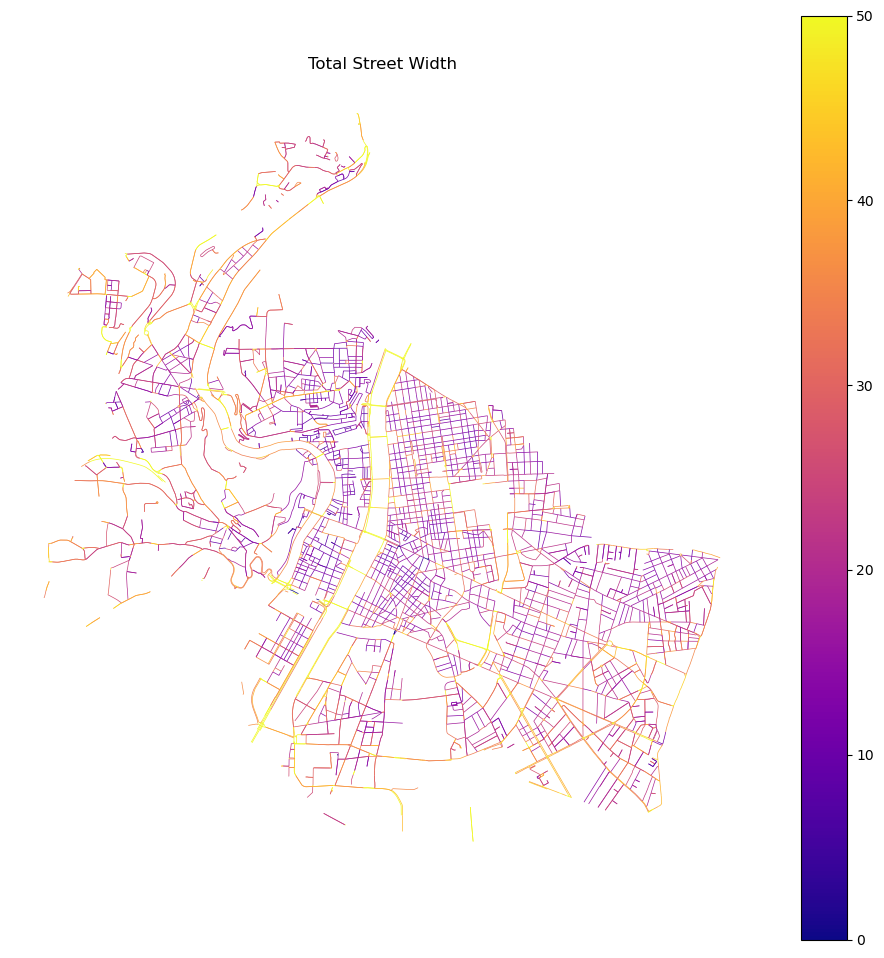

In [6]:
ax = edges.plot(cmap='plasma', column='width', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Total Street Width')
ax.set_axis_off()

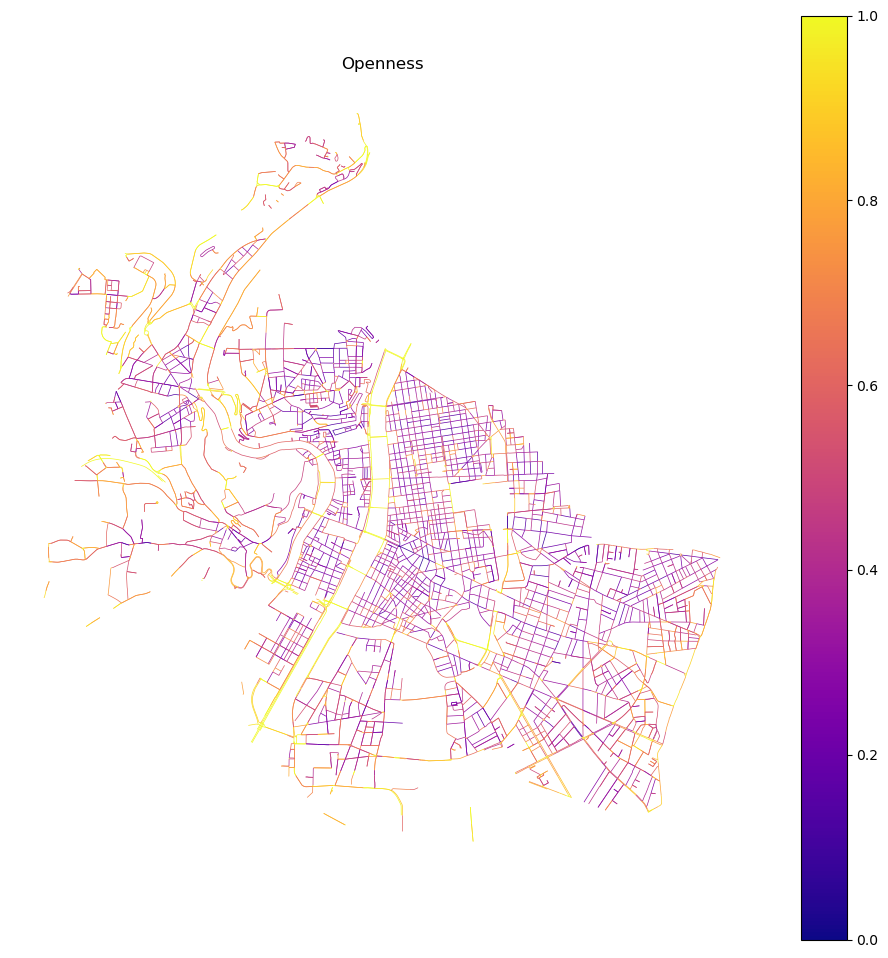

In [7]:
ax = edges.plot(cmap='plasma', column='openness', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Openness')
ax.set_axis_off()

# Centrality

Build the primal graph once; all centrality functions operate on it.

In momepy 0.11 all centralities are node-based. `mm.mean_nodes()` propagates each
node attribute to its incident edges (mean of the two endpoint values) before the
edge GeoDataFrame is extracted.

In [8]:
primal = mm.gdf_to_nx(edges, approach="primal")
print('Graph nodes:', primal.number_of_nodes(), '  edges:', primal.number_of_edges())

Graph nodes: 3880   edges: 7159


## Betweenness Centrality

In [9]:
betweenness = mm.betweenness_centrality(
    primal, name='betweenness_metric_e', mode='edges', weight='mm_len',
)

In [10]:
primal_gdf_betw = mm.nx_to_gdf(betweenness, points=False)
primal_gdf_betw.head()

,segment_id,highway,name,length,db_day,db_evening,db_night,noise_day,noise_evening,noise_night,geometry,width,openness,width_deviation,mm_len,betweenness_metric_e
0,143403_21714981_0,residential,Rue Professeur Morat,7.253513,75.146004,75.146004,64.759003,4,4,3,"LINESTRING (845997.628 6516651.325, 845991.441...",50.000000,1.0,NaN,7.261857,0.000286
1,21714981_143403_0,residential,Rue Professeur Morat,7.253513,75.146004,75.146004,64.759003,4,4,3,"LINESTRING (845991.441 6516647.523, 845997.628...",50.000000,1.0,NaN,7.261857,0.000286
2,143403_21718288_0,residential,Rue Professeur Morat,25.012168,70.842003,70.842003,60.486000,4,4,3,"LINESTRING (845997.628 6516651.325, 846002.531...",27.036067,0.7,6.985420,24.997594,0.000582
3,21718288_143403_0,residential,Rue Professeur Morat,25.012168,70.842003,70.842003,60.486000,4,4,3,"LINESTRING (846005.965 6516673.029, 846005.23 ...",25.748698,0.6,5.117014,24.997594,0.000582
4,143403_143408_0,primary,Avenue Jean Mermoz,102.443140,74.252998,74.252998,63.867001,4,4,3,"LINESTRING (845997.628 6516651.325, 845973.161...",31.248798,0.5,5.099725,102.589938,0.007972


Text(0.5, 1.0, 'Betweenness Centrality - Edge Mean (r=500 m)')

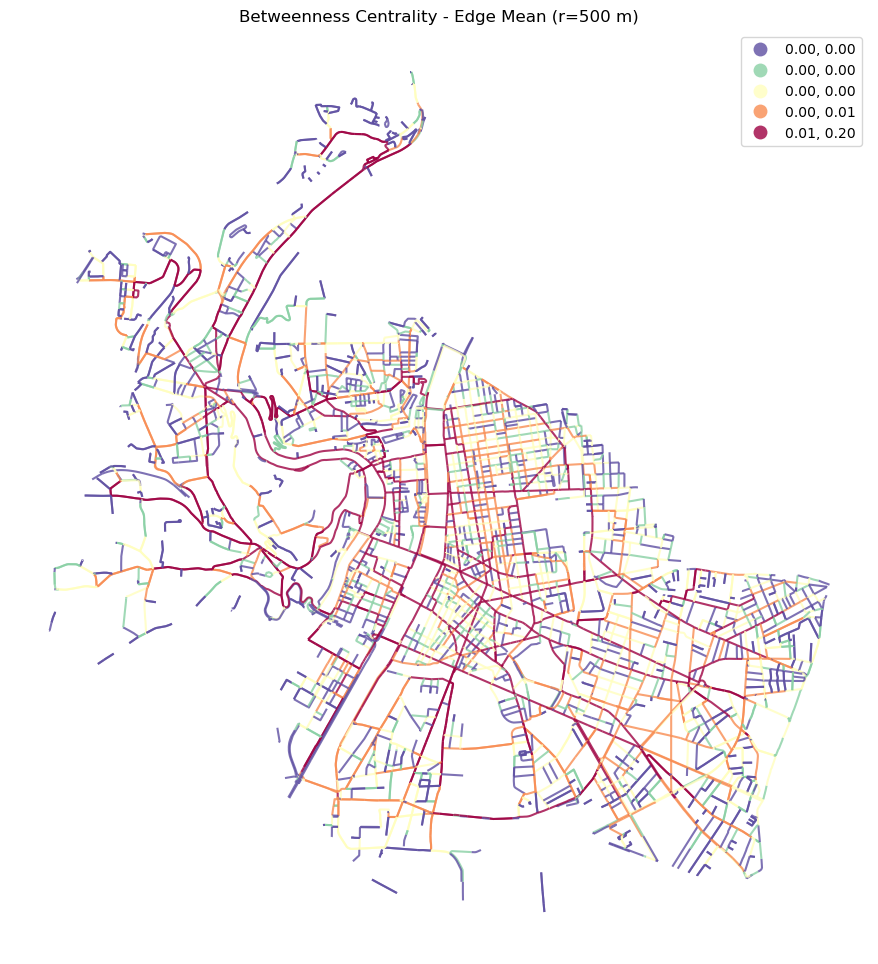

In [11]:
ax = primal_gdf_betw.plot(
    column='betweenness_metric_e',
    cmap='Spectral_r',
    scheme='quantiles',
    alpha=0.8,
    legend=True,
    figsize=(12, 12)
)
ax.set_axis_off()
ax.set_title('Betweenness Centrality - Edge Mean (r=500 m)')

## Global Closeness Centrality

Careful, takes a few minutes

In [12]:
closeness = mm.closeness_centrality(
    primal, name='closeness_global', weight='mm_len'
)

In [13]:
nodes = mm.nx_to_gdf(closeness, lines=False)
nodes.head()
nodes.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 3880 entries, 0 to 3879
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   x                 3880 non-null   float64 
 1   y                 3880 non-null   float64 
 2   closeness_global  3880 non-null   float64 
 3   nodeID            3880 non-null   int64   
 4   geometry          3880 non-null   geometry
dtypes: float64(3), geometry(1), int64(1)
memory usage: 151.7 KB


Text(0.5, 1.0, 'Closenness Global (Node Based)')

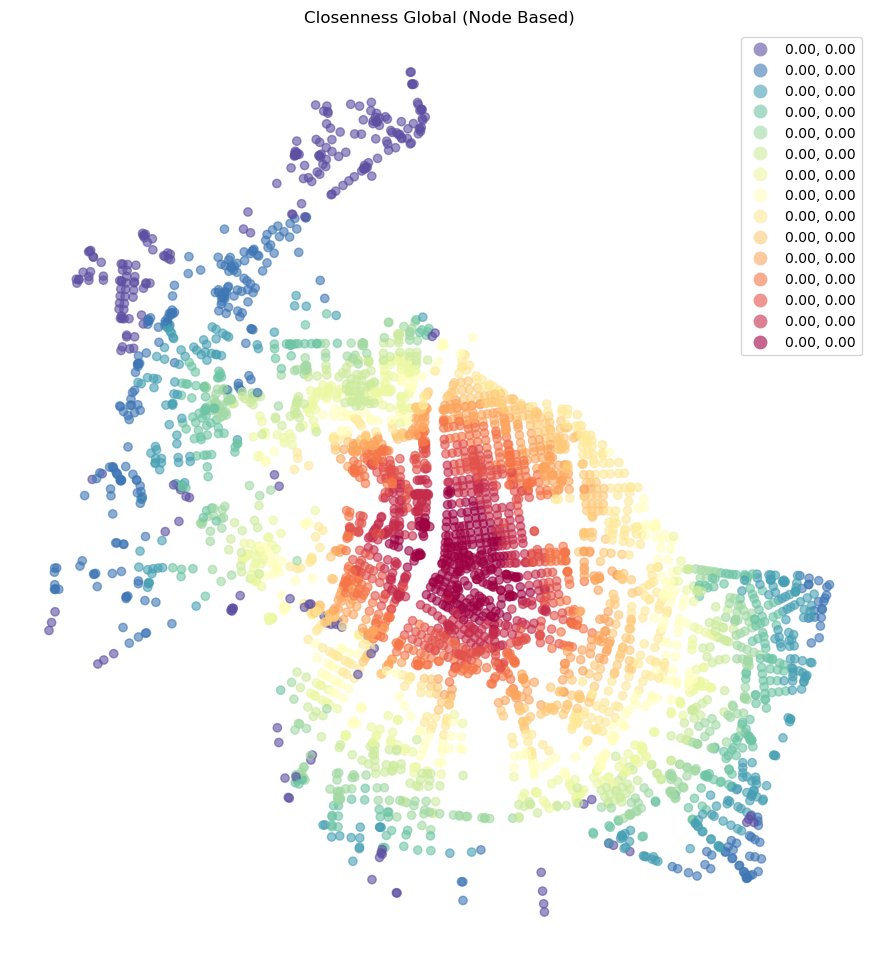

In [14]:
ax = nodes.plot(
    column="closeness_global",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(12, 12),
    legend=True
)
ax.set_axis_off()
ax.set_title("Closenness Global (Node Based)")

In [15]:
mm.mean_nodes(closeness, "closeness_global")

In [16]:
primal_gdf_clos = mm.nx_to_gdf(closeness, points=False)
primal_gdf_clos.head()

,segment_id,highway,name,length,db_day,db_evening,db_night,noise_day,noise_evening,noise_night,geometry,width,openness,width_deviation,mm_len,closeness_global
0,143403_21714981_0,residential,Rue Professeur Morat,7.253513,75.146004,75.146004,64.759003,4,4,3,"LINESTRING (845997.628 6516651.325, 845991.441...",50.000000,1.0,NaN,7.261857,0.000199
1,21714981_143403_0,residential,Rue Professeur Morat,7.253513,75.146004,75.146004,64.759003,4,4,3,"LINESTRING (845991.441 6516647.523, 845997.628...",50.000000,1.0,NaN,7.261857,0.000199
2,143403_21718288_0,residential,Rue Professeur Morat,25.012168,70.842003,70.842003,60.486000,4,4,3,"LINESTRING (845997.628 6516651.325, 846002.531...",27.036067,0.7,6.985420,24.997594,0.000198
3,21718288_143403_0,residential,Rue Professeur Morat,25.012168,70.842003,70.842003,60.486000,4,4,3,"LINESTRING (846005.965 6516673.029, 846005.23 ...",25.748698,0.6,5.117014,24.997594,0.000198
4,143403_143408_0,primary,Avenue Jean Mermoz,102.443140,74.252998,74.252998,63.867001,4,4,3,"LINESTRING (845997.628 6516651.325, 845973.161...",31.248798,0.5,5.099725,102.589938,0.000200


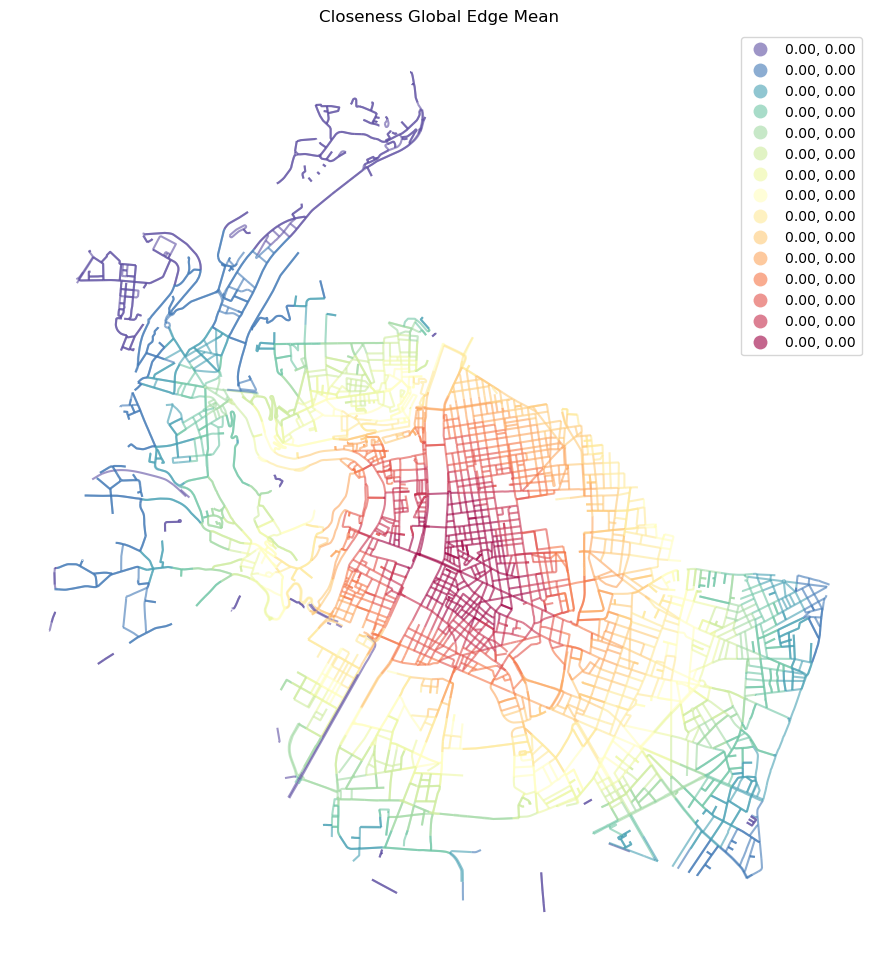

In [17]:

ax = primal_gdf_clos.plot(
    column="closeness_global",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(12, 12),
    legend=True
)
ax.set_axis_off()
_ = ax.set_title("Closeness Global Edge Mean")

## Local Closeness Centrality

In [18]:
local_clos = mm.closeness_centrality(
    primal, radius=400, name='closeness400', distance='mm_len', weight='mm_len'
)

  0%|          | 0/3880 [00:00<?, ?it/s]

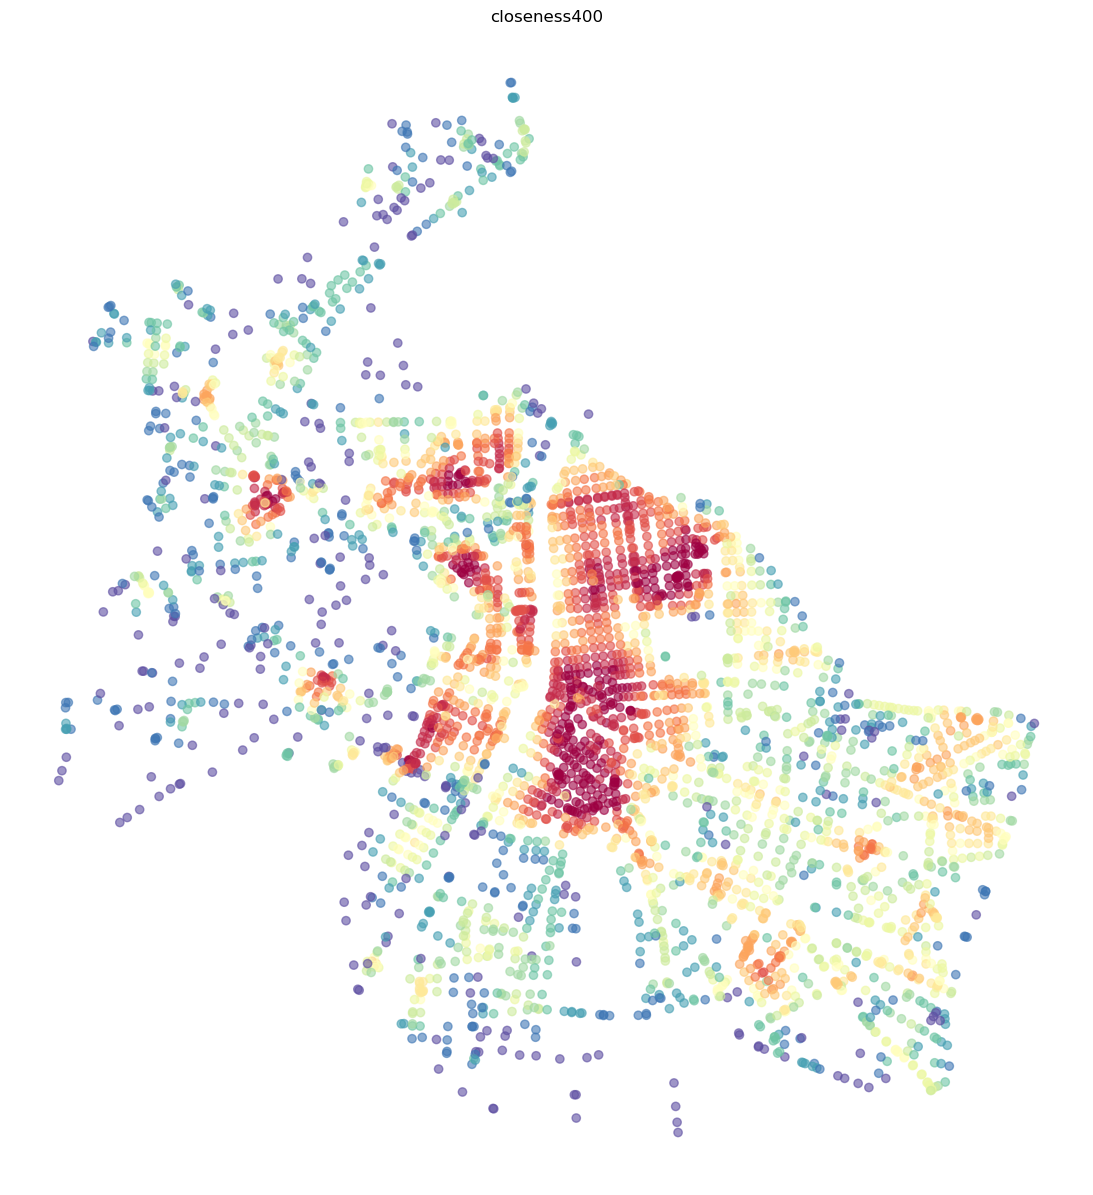

In [19]:
nodes = mm.nx_to_gdf(local_clos, lines=False)
ax = nodes.plot(
    column="closeness400",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title("closeness400")

In [20]:
mm.mean_nodes(local_clos, "closeness400")

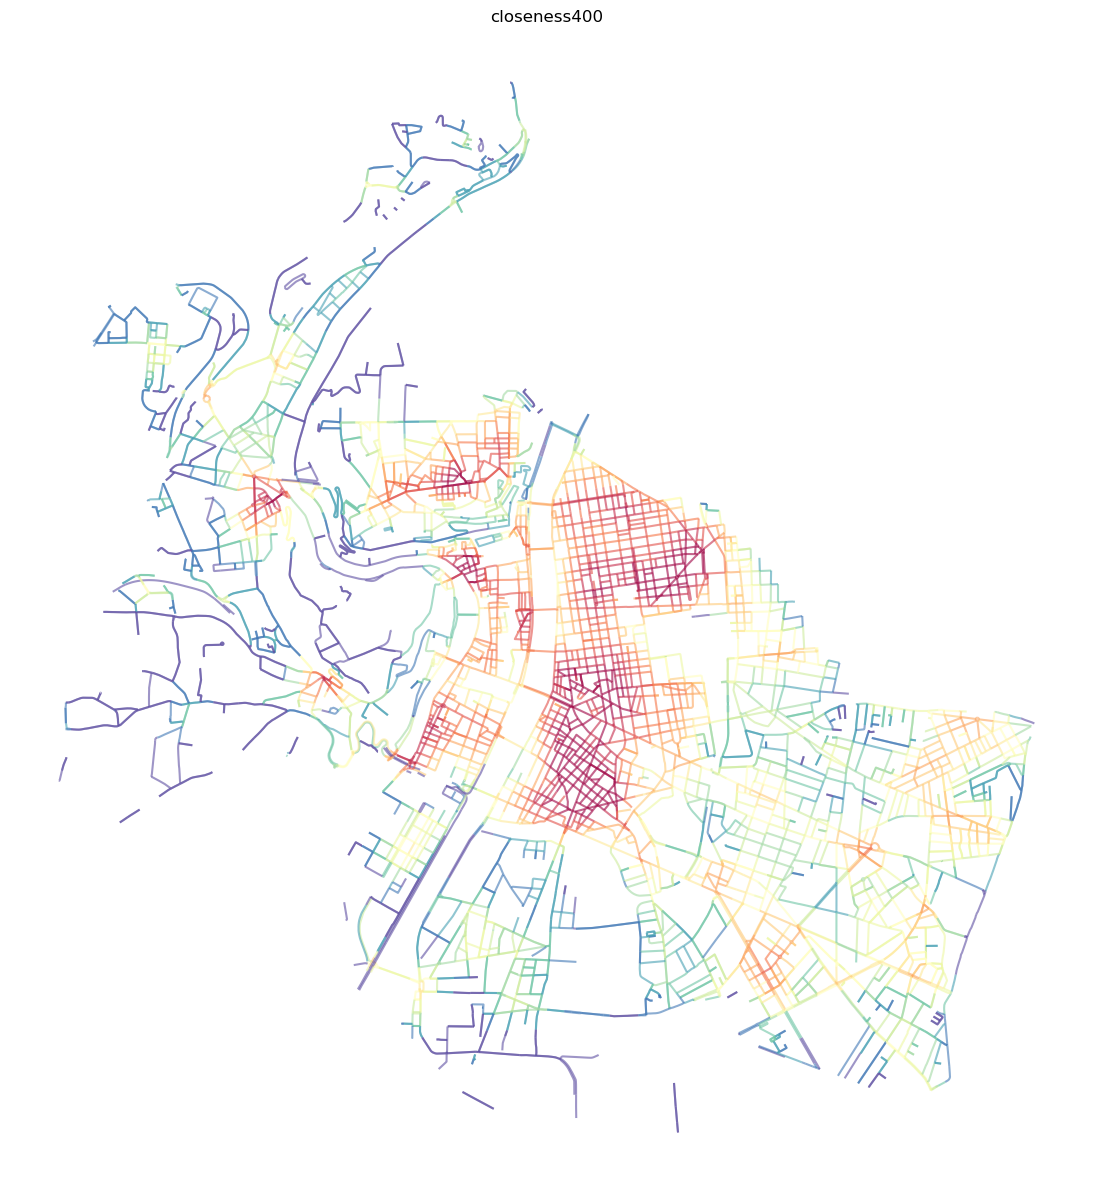

In [21]:
primal_gdf_clos400 = mm.nx_to_gdf(local_clos, points=False)

ax = primal_gdf_clos400.plot(
    column="closeness400",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title("closeness400")

## Straightness

In [22]:
straighteness = mm.straightness_centrality(
    primal
)

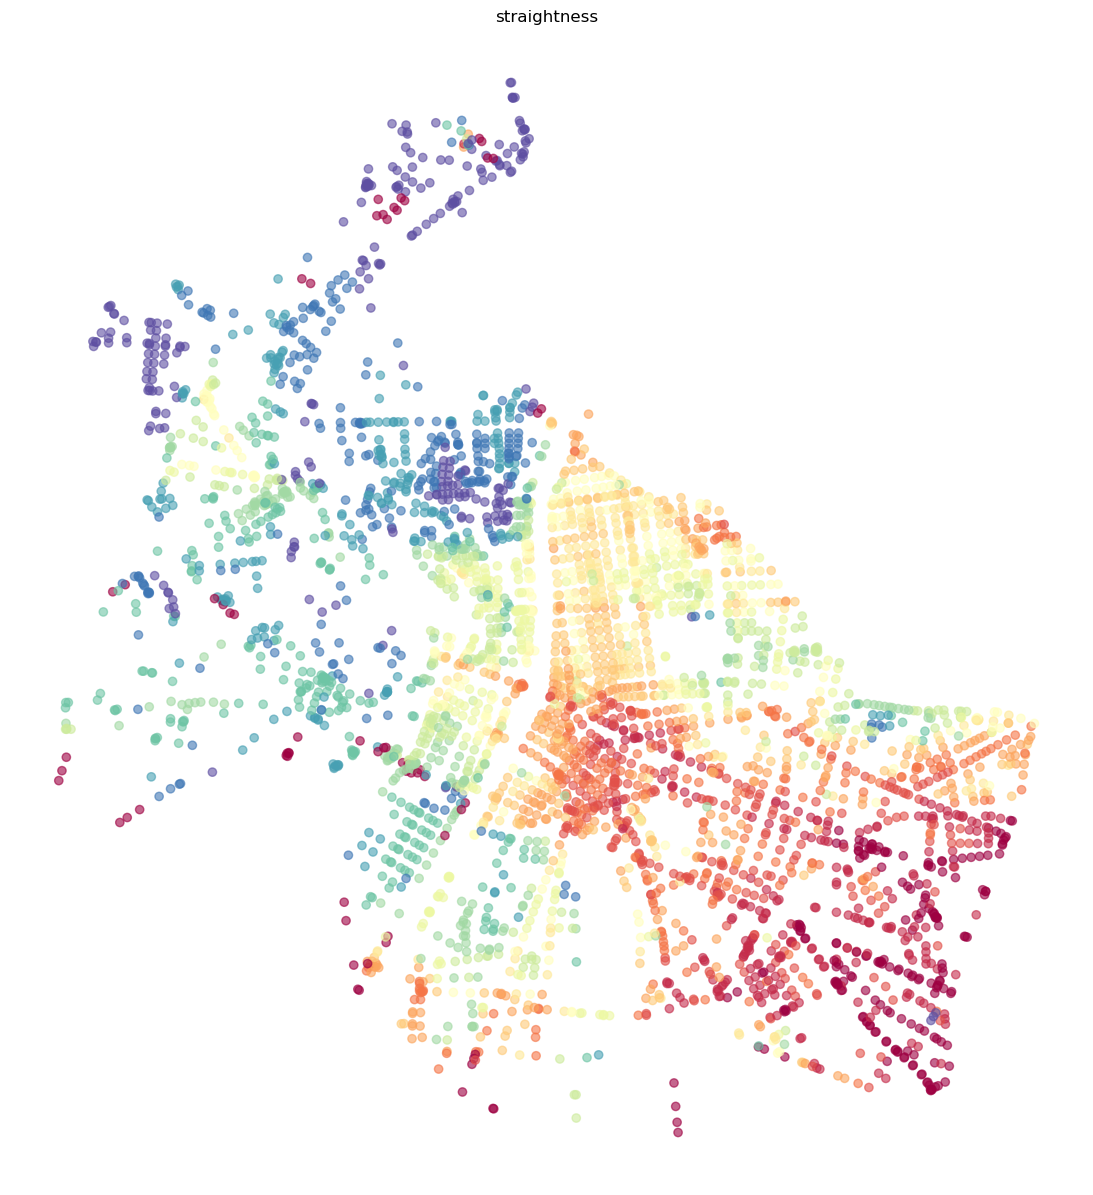

In [23]:
nodes = mm.nx_to_gdf(straighteness, lines=False)
ax = nodes.plot(
    column="straightness",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title("straightness")

In [24]:
mm.mean_nodes(straighteness, "straightness")

In [25]:
primal_gdf_str = mm.nx_to_gdf(straighteness, points=False)
primal_gdf_str.head()

,segment_id,highway,name,length,db_day,db_evening,db_night,noise_day,noise_evening,noise_night,geometry,width,openness,width_deviation,mm_len,straightness
0,143403_21714981_0,residential,Rue Professeur Morat,7.253513,75.146004,75.146004,64.759003,4,4,3,"LINESTRING (845997.628 6516651.325, 845991.441...",50.000000,1.0,NaN,7.261857,0.849272
1,21714981_143403_0,residential,Rue Professeur Morat,7.253513,75.146004,75.146004,64.759003,4,4,3,"LINESTRING (845991.441 6516647.523, 845997.628...",50.000000,1.0,NaN,7.261857,0.849272
2,143403_21718288_0,residential,Rue Professeur Morat,25.012168,70.842003,70.842003,60.486000,4,4,3,"LINESTRING (845997.628 6516651.325, 846002.531...",27.036067,0.7,6.985420,24.997594,0.845655
3,21718288_143403_0,residential,Rue Professeur Morat,25.012168,70.842003,70.842003,60.486000,4,4,3,"LINESTRING (846005.965 6516673.029, 846005.23 ...",25.748698,0.6,5.117014,24.997594,0.845655
4,143403_143408_0,primary,Avenue Jean Mermoz,102.443140,74.252998,74.252998,63.867001,4,4,3,"LINESTRING (845997.628 6516651.325, 845973.161...",31.248798,0.5,5.099725,102.589938,0.848310


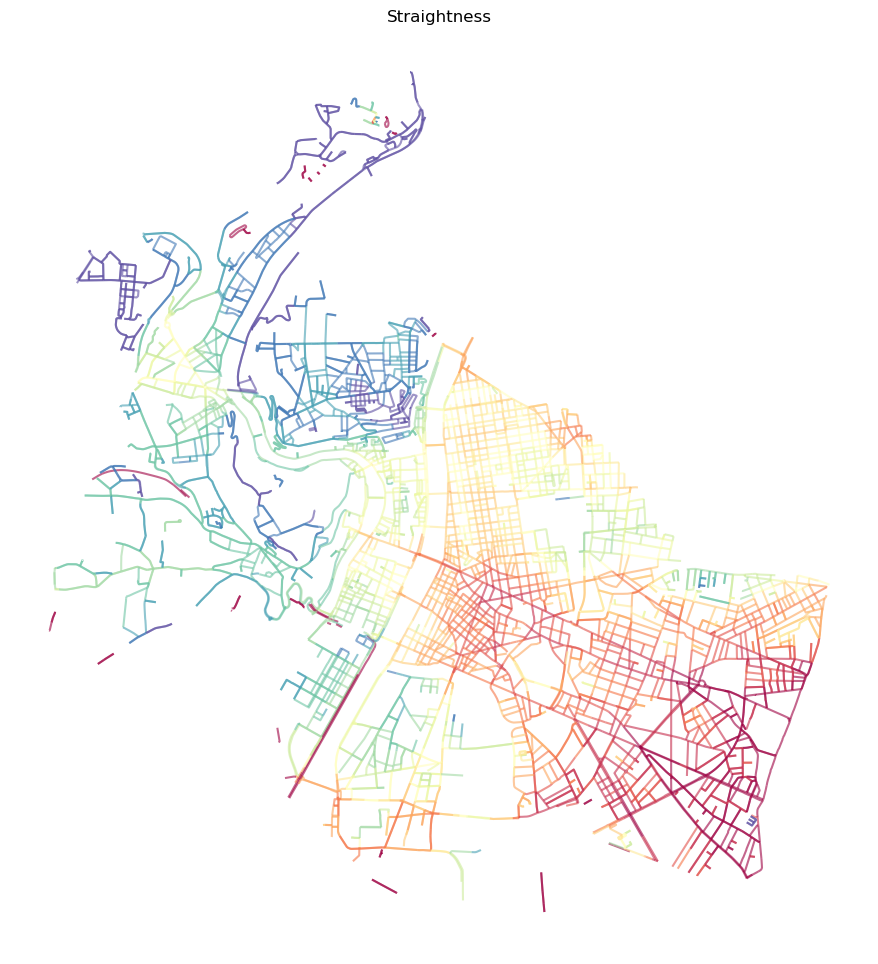

In [26]:
ax = primal_gdf_str.plot(
    column="straightness",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(12, 12),
)
ax.set_axis_off()
_ = ax.set_title("Straightness")

## Create data frame

In [27]:
dataset = edges[['segment_id', 'width', 'openness']].copy()

dataset = (
    dataset
    .merge(primal_gdf_betw[['segment_id', 'betweenness_metric_e']], on='segment_id', how='left')
    .merge(primal_gdf_clos[['segment_id', 'closeness_global']], on='segment_id', how='left')
    .merge(primal_gdf_clos400[['segment_id', 'closeness400']], on='segment_id', how='left')
    .merge(primal_gdf_str[['segment_id', 'straightness']], on='segment_id', how='left')
    .rename(columns={
        'segment_id': 'road_id',
        'betweenness_metric_e': 'betweenness',
        'closeness400': 'closeness_400'
    })
    .fillna(0)
)

dataset.head()

,road_id,width,openness,betweenness,closeness_global,closeness_400,straightness
0,143403_21714981_0,50.000000,1.000000,0.000286,0.000199,0.000028,0.849272
1,143403_21718288_0,27.036067,0.700000,0.000582,0.000198,0.000027,0.845655
2,143403_143408_0,31.248798,0.500000,0.007972,0.000200,0.000026,0.848310
3,143408_21718264_0,20.502936,0.355263,0.001119,0.000204,0.000024,0.841243
4,143408_932576340_0,33.348257,0.409091,0.008019,0.000204,0.000023,0.846601


## Export dataset to CSV

In [28]:
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "momepy_roads_features.csv"), index=False)
print("Exported momepy_roads_features.csv")

Exported momepy_roads_features.csv
